In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import torchdiffeq


# Configuration
target = 'squiggly'  # Choose from 'guassian', 'ring', 'banana', 'squiggly', 'checkerboard', 'spirals'
device = torch.device("mps" if torch.backends.mps.is_available() 
                      else "cuda" if torch.cuda.is_available() 
                      else "cpu")
device = torch.device('cpu')
print(device)



cpu


In [5]:
# Define the target distribution and its gradient
if target == 'spirals':
    def target_distribution(pos):
        x = pos.reshape(-1, 2)
        theta = torch.atan2(x[:, 1], x[:, 0]) + 2 * torch.pi
        r = torch.sqrt(x[:, 0]**2 + x[:, 1]**2)
        density = torch.exp(-4 * 0.5 * ((r - (theta / (2 * torch.pi) * 4)) ** 2))  # Decreased radius
        return density.reshape(pos.shape[:-1])

    def grad_log_p(x):
        theta = torch.atan2(x[:, 1], x[:, 0]) + 2 * torch.pi
        r = torch.sqrt(x[:, 0]**2 + x[:, 1]**2)
        print((r - (theta / (2 * torch.pi) * 4)).shape)
        grad_r = (r - (theta / (2 * torch.pi) * 4)) * x / r.unsqueeze(1)  # Decreased radius
        grad_theta = (r - (theta / (2 * torch.pi) * 4)) * torch.stack([-x[:, 1], x[:, 0]], dim=-1) / (r.unsqueeze(1)**2)
        return -4 * (grad_r + grad_theta)
    
elif target == 'squiggly':
    # Define the target distribution: Squiggly distribution
    def target_distribution(x):
        x1, x2 = x[:,:, 0], x[:,:, 1]
        return torch.exp(-0.25 * ((x2 - torch.sin(3 * x1)) ** 2 / 0.1))

    def grad_log_p(x):
        if x.ndim == 1:
            x = x.reshape(1, -1)
        x1, x2 = x[:, 0], x[:, 1]
        grad_x1 = -3 * torch.cos(3 * x1) * (x2 - torch.sin(3 * x1)) / 0.1
        grad_x2 = -(x2 - torch.sin(3 * x1)) / 0.1
        return  0.5 * torch.column_stack((grad_x1, grad_x2))
elif target == 'banana':
    # Banana distribution
    def target_distribution(x):

        x1, x2 = x[..., 0], x[..., 1]
        return torch.exp(-2.0 * ((x1**2 / 100) + (x2 + 0.03 * x1**2 - 3) ** 2))

    def grad_log_p(x):

        x1, x2 = x[..., 0], x[..., 1]
        grad_x1 = -x1 / 50 - 0.06 * x1 * (x2 + 0.03 * x1**2 - 3)
        grad_x2 = -(x2 + 0.03 * x1**2 - 3)
        return torch.stack((grad_x1, grad_x2), dim=-1)
elif target == 'ring':
    def target_distribution(x):
        radius = 4
        norm_x = torch.norm(x, dim=-1)
        return torch.exp(-2.0 * (norm_x - radius) ** 2)
    def grad_log_p(x):
        radius = 4
        norm_x = torch.norm(x, dim=-1, keepdim=True)
        return -4.0 * (norm_x - radius) * x / norm_x
    
elif target == 'gaussian':
    def target_distribution(x):
        if x.device.type == 'mps':
            x = x.cpu()
        
        mean1, cov1 = torch.tensor([2.0, 2.0]), torch.tensor([[0.5, 0.1], [0.1, 0.5]])
        mean2, cov2 = torch.tensor([-2.0, -2.0]), torch.tensor([[0.5, -0.1], [-0.1, 0.5]])
        pdf1 = torch.exp(-0.5 * torch.sum((x - mean1) @ torch.linalg.inv(cov1) * (x - mean1), dim=-1)) / torch.sqrt(torch.det(cov1) * (2 * torch.pi) ** 2)
        pdf2 = torch.exp(-0.5 * torch.sum((x - mean2) @ torch.linalg.inv(cov2) * (x - mean2), dim=-1)) / torch.sqrt(torch.det(cov2) * (2 * torch.pi) ** 2)
        pdf1 = pdf1.to(device)
        pdf2 = pdf2.to(device)
        return 0.5 * pdf1 + 0.5 * pdf2

    def grad_log_p(x):
        if x.device.type == 'mps':
            x = x.cpu()
        
        mean1, cov1 = torch.tensor([2.0, 2.0]), torch.tensor([[0.5, 0.1], [0.1, 0.5]])
        mean2, cov2 = torch.tensor([-2.0, -2.0]), torch.tensor([[0.5, -0.1], [-0.1, 0.5]])
        pdf1 = torch.exp(-0.5 * torch.sum((x - mean1) @ torch.linalg.inv(cov1) * (x - mean1), dim=-1)) / torch.sqrt(torch.det(cov1) * (2 * torch.pi) ** 2)
        pdf2 = torch.exp(-0.5 * torch.sum((x - mean2) @ torch.linalg.inv(cov2) * (x - mean2), dim=-1)) / torch.sqrt(torch.det(cov2) * (2 * torch.pi) ** 2)
        grad1 = -(x - mean1) @ torch.linalg.inv(cov1).T
        grad2 = -(x - mean2) @ torch.linalg.inv(cov2).T
        d_log_p = 0.5 * (grad1 * pdf1[:, None] + grad2 * pdf2[:, None]) / (pdf1 + pdf2).unsqueeze(-1)
        d_log_p = d_log_p.to(device)
        return d_log_p
elif target == 'checkerboard':
    def target_distribution(x):
        device = x.device
        x1, x2 = x[:,:, 0], x[:,:, 1]
        
        scale = 3.0  # Adjust this scale to control the size of the squares
    
        checkered = ((torch.floor(x1 / scale) + torch.floor(x2 / scale)) % 2 == 0).float()
        return checkered        

    def grad_log_p(x):
        # Gradient is zero everywhere for a checkerboard pattern as it is piecewise constant
        return torch.zeros_like(x)


 
else:
    raise ValueError("Invalid target distribution")





In [6]:
def make_plot(iteration, particles, updates, kernel_matrix, bandwidth):

    print(f'Iteration {iteration}, Bandwidth: {bandwidth}')
    plt.figure(figsize=(4, 4))
    # plt.imshow(kernel_matrix.cpu().numpy())
    # plt.colorbar()
    # plt.title('Kernel Matrix')

    x, y = torch.meshgrid(torch.linspace(-5, 5, 100), torch.linspace(-5, 5, 100))
    pos = torch.stack((x, y), dim=-1).to(particles.device)
    targets = target_distribution(pos).cpu().numpy()
    plt.contourf(x.cpu(), y.cpu(), targets, levels=5, cmap='viridis', alpha=0.5)
    plt.colorbar(label='Target Density')

    # Scatter plot of particles
    plt.scatter(particles[:, 0].cpu(), particles[:, 1].cpu(), color='red', s=10, label='Particles')

    arrow_scale = 2
    magnitudes = torch.norm(updates, dim=1)  
    max_magnitude = magnitudes.max().item()

    # Scale gradients so the largest has unit length
    updates = updates / (max_magnitude + 1e-8) * arrow_scale


    # Add arrows for particle movement
    for i, (particle, update) in enumerate(zip(particles, updates)):
        plt.arrow(
            particle[0].cpu().item(),
            particle[1].cpu().item(),
            update[0].cpu().item(),
            update[1].cpu().item(),
            color='blue',
            width=0.01,
            head_width=0.1,
            head_length=0.5,
            length_includes_head=True,
            alpha=0.8,
        )
    
    # Plot settings
    plt.title(f'Particle Movements at Iteration {iteration}')
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.grid(False)
    plt.show()


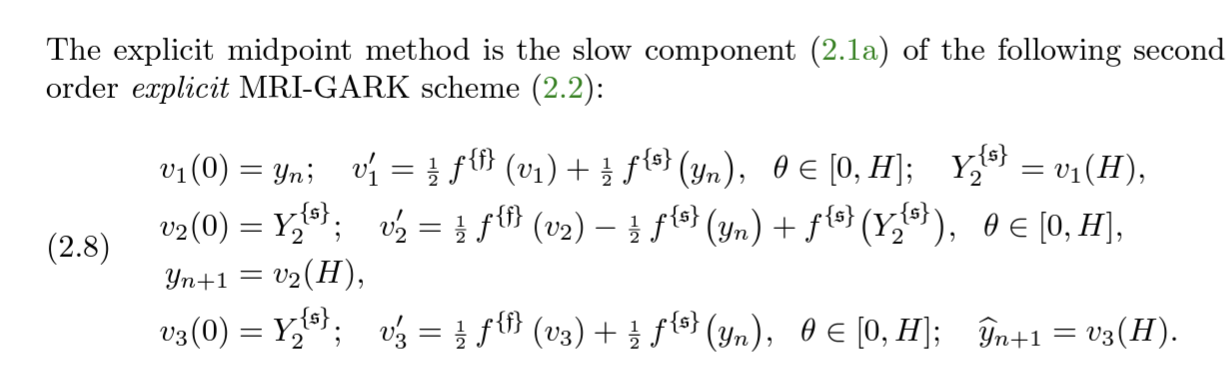

In [7]:
def mriGARKstep(particles, f_slow, f_fast, step_size):

    t    = torch.tensor(0.0).to(particles.device)
    v1        = particles.clone() 
    fs        = f_slow(0, particles)
    stage_ode = lambda t, v: 0.5*f_fast(t, v) + 0.5*fs
    v2        = torchdiffeq.odeint(stage_ode, v1,
                                    torch.tensor([0, step_size],
                                    device=particles.device))[-1,:,:]
    # t         = t + step_size  autonoumous system time is not needed
    
    fs2       = f_slow(0, v2)
    stage_ode = lambda t, v: 0.5*f_fast(t,v)  -0.5*fs + fs2
    ynext     = torchdiffeq.odeint(stage_ode, v2,
                                    torch.tensor([0, step_size],
                                    device=particles.device))[-1,:,:]
    v3        = v2
    stage_ode = lambda t, v: 0.5*f_fast(t, v) + 0.5*fs
    yhat      = torchdiffeq.odeint(stage_ode, v3,
                                    torch.tensor([0, step_size],
                                    device=particles.device))[-1,:,:]
    return ynext, yhat



In [186]:
class FlopCounter:
    def __init__(self):
        self.flops = 0  # Initialize total FLOP count

    def count_matmul(self, A, B):
        # Matrix multiplication (A @ B)
        m, n = A.shape
        n, p = B.shape
        # Matmul FLOPs: 2 * m * n * p
        self.flops += 2 * m * n * p

    def count_addition(self, A, B):
        # Element-wise addition of A and B
        self.flops += A.numel()  # Each element adds one FLOP

    def count_subtraction(self, A, B):
        # Element-wise subtraction of A and B
        self.flops += A.numel()  # Each element adds one FLOP

    def count_elementwise_mul(self, A, B):
        # Element-wise multiplication of A and B
        self.flops += A.numel()  # Each element adds one FLOP

    def count_elementwise_div(self, A, B):
        # Element-wise division of A and B
        self.flops += A.numel()  # Each element adds one FLOP

    def count_exp(self, A):
        # Element-wise exponentiation
        self.flops += A.numel()  # One FLOP per element

    def get_flops(self):
        return self.flops



def svgd_integrate_mri(particles, grad_log_p, target_distribution, t_final, bandwidth=0.5, counter=None):
    all_particles = []
    flop_history = []
    time_history = []
    ess_history = []
    mlp_history = []
    kl_history = []
    spread_history = []

    step_size = 2*0.5
    t = torch.tensor(0.0, device=particles.device)

    while t < t_final:
        # Compute the kernel matrix for SVGD
        distances = torch.cdist(particles, particles) ** 2
        counter.count_subtraction(particles.unsqueeze(1), particles.unsqueeze(0))  # Subtraction for distance
        counter.count_exp(distances)  # Exponentiation for kernel matrix
        kernel_matrix = torch.exp(-distances / (2 * bandwidth**2))  # Kernel matrix computation
        counter.count_elementwise_div(kernel_matrix, 2 * bandwidth**2)  # Division for kernel matrix

        def f_fast(t, particles):
            kernel_grad = -(particles.unsqueeze(1) - particles.unsqueeze(0)) * kernel_matrix.unsqueeze(-1) / (bandwidth**2)
            return 1*kernel_grad.sum(dim=0) / len(particles)
        
        def f_slow(t, particles):
            # Compute SVGD direction
            grad_log_p_values = grad_log_p(particles)
            svgd_direction_slow = kernel_matrix @ grad_log_p_values / len(particles)
            return svgd_direction_slow 

        # Compute kernel gradient (SVGD update)
        kernel_grad = -(particles.unsqueeze(1) - particles.unsqueeze(0)) * kernel_matrix.unsqueeze(-1) / (bandwidth**2)
        counter.count_subtraction(particles.unsqueeze(1), particles.unsqueeze(0))  # Subtraction
        counter.count_elementwise_mul(kernel_grad, kernel_matrix.unsqueeze(-1))  # Element-wise multiplication
        counter.count_elementwise_div(kernel_grad, bandwidth**2)  # Division

        grad_log_p_values = grad_log_p(particles)
        counter.count_matmul(kernel_matrix, grad_log_p_values)  # Matrix multiplication for SVGD update

        # Simulate ODE with Runge-Kutta method (not modified, just counting flops in mriGARKstep)
        ynext, yhat = mriGARKstep(particles, f_slow, f_fast, step_size)
        relative_error = torch.norm(ynext - yhat) / torch.clamp(torch.norm(ynext), min=1e-6)
        
        if relative_error > 1e-1:
            print(f'rejected step time: {t}, step size: {step_size}, relative error: {relative_error}')
            step_size = 0.8* step_size 
            continue
        else:
            print('accepted step time:', t.item(), 'step size:', step_size)
            t = t + step_size
            step_size = step_size * 1.2
            particles = ynext.clone()

            # # Kernel-smoothed target distribution gradient
            weights = target_distribution(particles.unsqueeze(0)).squeeze().unsqueeze(1)
            kernel_grad = (particles.unsqueeze(1) - particles.unsqueeze(0)) * kernel_matrix.unsqueeze(-1) / ((2*bandwidth)**2)
            grad_p_smooth = (kernel_grad * weights.unsqueeze(-1)).sum(dim=0) / len(particles)
            particles = particles + 0*step_size * grad_p_smooth
            # make_plot(t, particles, grad_p_smooth, kernel_matrix, bandwidth)
            all_particles.append(ynext)

            mlp = mean_log_p(particles, target_distribution)
            ess = effective_sample_size(particles, target_distribution)
            kl = kl_divergence(particles, target_distribution)
            spread  = compute_sample_spread(particles)
            


            # Track history
            flop_history.append(counter.get_flops())
            time_history.append(t)  # Elapsed time
            mlp_history.append(mlp)
            ess_history.append(ess)
            kl_history.append(kl)
            spread_history.append(spread)


    history = {
            'flop_history': flop_history,
            'time_history': time_history,
            'ess_history': ess_history,
            'mlp_history': mlp_history,
            'kl_history': kl_history,
            'spread_history': spread_history
        
        }

    return all_particles, history



In [187]:
def svgd(particles, grad_log_p, target_distribution, t_final, bandwidth=0.5, counter=None):
    """
    Vanilla SVGD Implementation with FLOP Counting and History Tracking
    """
    all_particles = []
    flop_history = []
    time_history = []
    ess_history = []
    mlp_history = []
    kl_history = []
    spread_history = []

    step_size = 0.5
    t = torch.tensor(0.0, device=particles.device)

    while t < t_final:
        # Compute the kernel matrix
        distances = torch.cdist(particles, particles) ** 2
        counter.count_subtraction(particles.unsqueeze(1), particles.unsqueeze(0))  # Subtraction for distance
        counter.count_exp(distances)  # Exponentiation for kernel matrix
        kernel_matrix = torch.exp(-distances / (2 * bandwidth**2))  # Kernel matrix computation
        counter.count_elementwise_div(kernel_matrix, 2 * bandwidth**2)  # Division for kernel matrix

        # Compute SVGD update direction
        grad_log_p_values = grad_log_p(particles)
        counter.count_matmul(kernel_matrix, grad_log_p_values)  # Matrix multiplication
        svgd_direction = kernel_matrix @ grad_log_p_values / len(particles)
        counter.count_elementwise_div(svgd_direction, len(particles))  # Division for normalization

        # Update particles
        particles = particles + step_size * svgd_direction
        counter.count_elementwise_mul(svgd_direction, step_size)  # Multiplication for step size update
        counter.count_addition(particles, svgd_direction)  # Element-wise addition for update

        # Track history
        mlp = mean_log_p(particles, target_distribution)
        ess = effective_sample_size(particles, target_distribution)
        kl = kl_divergence(particles, target_distribution)
        spread  = compute_sample_spread(particles)

        flop_history.append(counter.get_flops())
        time_history.append(t)
        mlp_history.append(mlp)
        ess_history.append(ess)
        kl_history.append(kl)
        spread_history.append(spread)


        t = t + step_size
        all_particles.append(particles.clone())

    # Combine histories into a dictionary
    history = {
        'flop_history': flop_history,
        'time_history': time_history,
        'ess_history': ess_history,
        'mlp_history': mlp_history,
        'kl_history': kl_history,
        'spread_history': spread_history
    }

    return all_particles, history


In [188]:
def mean_log_p(particles, target_distribution):
    # Quality metric based on log-likelihood of the target distribution
    log_p = target_distribution(particles.unsqueeze(0)).squeeze()
    return log_p.mean().item()  # Return the mean log-probability as the quality metric

def effective_sample_size(particles, target_distribution):
    weights = target_distribution(particles.unsqueeze(0)).squeeze()
    # Normalize weights
    weights = target_distribution(particles.unsqueeze(0)).squeeze()
    normalized_weights = weights / weights.sum()
    
    # Compute ESS
    ess = 1.0 / torch.sum(normalized_weights ** 2)
    
    return ess.item()

def kl_divergence(particles, target_distribution, bandwidth=0.5):
    device = particles.device
    N, D = particles.shape

    # Estimate particle density with RBF kernel density estimation
    distances = torch.cdist(particles, particles) ** 2
    kernel_matrix = torch.exp(-distances / (2 * bandwidth**2))
    particle_density = kernel_matrix.sum(dim=1) / (N * (2 * torch.pi * bandwidth**2) ** (D / 2))

    # Evaluate target distribution
    target_density = target_distribution(particles.unsqueeze(0)).squeeze().clamp(min=1e-12)  # Avoid log(0)

    # Estimate KL divergence
    kl = torch.mean(torch.log(particle_density) - torch.log(target_density))
    return kl.item()


def compute_sample_spread(samples):
    # Compute pairwise distances (squared Euclidean distance)
    pairwise_distances = torch.cdist(samples, samples, p=2) ** 2

    # Exclude self-distances (diagonal)
    num_samples = samples.size(0)
    spread = pairwise_distances.sum() / (num_samples * (num_samples - 1))  # Average over all pairs

    return spread.item()

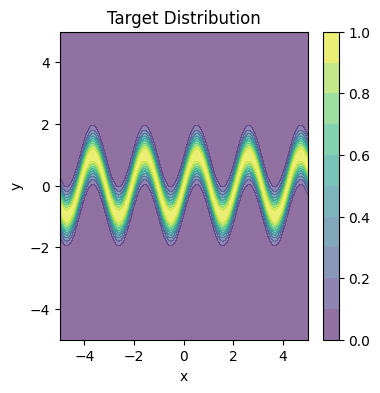

In [189]:
import torch
import matplotlib.pyplot as plt

# Define the grid for visualization
grid_size = 0.01
x = torch.arange(-5, 5, grid_size)
y = torch.arange(-5, 5, grid_size)
x, y = torch.meshgrid(x, y, indexing='ij')  # Create a mesh grid
pos = torch.stack((x, y), dim=-1)  # Combine x and y into a single tensor of shape (500, 500, 2)

# Evaluate the target distribution on the grid
dist = target_distribution(pos)  # Using the PyTorch-based target_distribution
dist = dist.reshape(x.shape)  # Reshape to match the grid for plotting

# Plot using Matplotlib
fig, ax = plt.subplots(figsize=(4, 4))
contour = ax.contourf(x.numpy(), y.numpy(), dist.numpy(), levels=10, cmap='viridis', alpha=0.6)
plt.colorbar(contour)
plt.title("Target Distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [190]:
# Visualization function
def plot_particles(particles, target_distribution, iteration):
    plt.figure(figsize=(8, 6))
    x, y = torch.meshgrid(torch.linspace(-5, 5, 100), torch.linspace(-5, 5, 100))
    pos = torch.stack((x, y), dim=-1).to(device)
    targets = target_distribution(pos).cpu().numpy()

    plt.contourf(x.cpu(), y.cpu(), targets, levels=30, cmap='viridis', alpha=0.6)
    plt.scatter(particles[:, 0].cpu(), particles[:, 1].cpu(), color='red', s=10)
    plt.title(f'Iteration {iteration}')
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.show()




In [191]:

# Initialize particles
num_particles = 100
particles = (torch.rand(num_particles, 2) - 0.5) * 10
particles = particles.to(device)
t_final = 100.0


# Instantiate flop counter
flop_counter_svgd = FlopCounter()
flop_counter_mri = FlopCounter()

# Run the SVGD integration
all_particles_mri, history_mri = svgd_integrate_mri(particles, grad_log_p, target_distribution, t_final=t_final, 
                                   bandwidth=0.5, counter=flop_counter_mri)

all_particles_svgd, history_svgd = svgd(particles, grad_log_p, target_distribution, t_final=t_final, 
                                   bandwidth=0.5, counter=flop_counter_svgd)





rejected step time: 0.0, step size: 1.0, relative error: 0.10056043416261673
accepted step time: 0.0 step size: 0.8
rejected step time: 0.800000011920929, step size: 0.96, relative error: 0.14548926055431366
accepted step time: 0.800000011920929 step size: 0.768
rejected step time: 1.568000078201294, step size: 0.9216, relative error: 0.20091813802719116
rejected step time: 1.568000078201294, step size: 0.73728, relative error: 0.13280172646045685
accepted step time: 1.568000078201294 step size: 0.589824
rejected step time: 2.1578240394592285, step size: 0.7077888, relative error: 0.11343016475439072
accepted step time: 2.1578240394592285 step size: 0.56623104
accepted step time: 2.724055051803589 step size: 0.679477248
accepted step time: 3.4035322666168213 step size: 0.8153726976
rejected step time: 4.218904972076416, step size: 0.9784472371199999, relative error: 0.13926661014556885
accepted step time: 4.218904972076416 step size: 0.782757789696
accepted step time: 5.001662731170654

In [194]:
all_particles = all_particles_mri.copy()
# Convert particles to a single stacked tensor for easier handling
all_particles = torch.stack(all_particles, dim=0)  # Shape: (num_iterations, num_particles, 2)

# Create animation
fig, ax = plt.subplots(figsize=(4, 4))

# Define the grid for the target distribution plot
grid_size = 0.01
x = torch.arange(-5, 5, grid_size, device=device)
y = torch.arange(-5, 5, grid_size, device=device)
x, y = torch.meshgrid(x, y, indexing="ij")
pos = torch.stack((x, y), dim=-1)
dist = target_distribution(pos).cpu()  # Evaluate the target distribution on the grid

# Convert to NumPy for Matplotlib plotting
x_np, y_np = x.cpu().numpy(), y.cpu().numpy()
dist_np = dist.numpy()

# Plot the target distribution
contour = ax.contourf(x_np, y_np, dist_np, levels=20, cmap="plasma", alpha=0.6)


# # Adjust the contour plot using the function
# adjust_contour_plot(ax, title='Contour Plot', xlabel='X-axis', ylabel='Y-axis', colorbar_label='Intensity', colormap='plasma', line_width=1.0, line_color='black')

# Initialize the scatter plot for particles
scatter = ax.scatter([], [], color="red", s=10)

# Update function for animation
def update(frame):
    scatter.set_offsets(all_particles[frame].cpu().numpy())  # Update particle positions
    ax.set_title(f"Iteration {frame}")
    return scatter,

# Create the animation
ani = FuncAnimation(fig, update, frames=all_particles.shape[0], blit=True)

# Display the animation
plt.close(fig)  # Close the static plot
HTML(ani.to_jshtml())

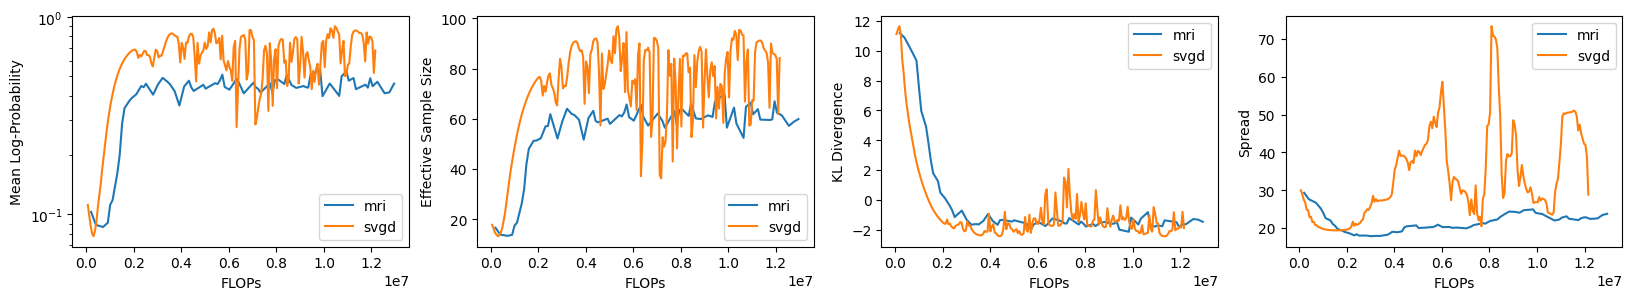

In [193]:
# Create a figure
fig = plt.figure(figsize=(12+8, 3))

# Create a list of axes
axes = [fig.add_subplot(1, 4, i+1) for i in range(4)]

for experiment, history in zip(['mri', 'svgd'], [history_mri, history_svgd]):
    # Plot the quality metric (mean log-probability) over time
    axes[0].semilogy(history['flop_history'], history['mlp_history'], label=experiment)
    axes[0].set_xlabel('FLOPs')
    axes[0].set_ylabel('Mean Log-Probability')

    # Plot the effective sample size over time
    axes[1].plot(history['flop_history'], history['ess_history'], label=experiment)
    axes[1].set_xlabel('FLOPs')
    axes[1].set_ylabel('Effective Sample Size')

    # Plot the KL divergence over time
    axes[2].plot(history['flop_history'], history['kl_history'], label=experiment)
    axes[2].set_xlabel('FLOPs')
    axes[2].set_ylabel('KL Divergence')

    axes[3].plot(history['flop_history'], history['spread_history'], label=experiment)
    axes[3].set_xlabel('FLOPs')
    axes[3].set_ylabel('Spread')
  


# Turn legend on for all subplots
for ax in axes:
    ax.legend()

# Show the plot
plt.show()

In [180]:
def adjust_contour_plot(ax, title='', xlabel='', ylabel='', colorbar_label='', colormap='viridis', line_width=0.5, line_color='black'):
    """
    Adjusts the look of a matplotlib contour plot.

    Parameters:
    ax (matplotlib.axes._subplots.AxesSubplot): The axes object containing the contour plot.
    title (str): The title of the plot.
    xlabel (str): The label for the x-axis.
    ylabel (str): The label for the y-axis.
    colorbar_label (str): The label for the colorbar.
    colormap (str): The colormap to be used for the contour plot.
    line_width (float): The width of the contour lines.
    line_color (str): The color of the contour lines.
    """
    
    # Set title and labels
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    # Get the contour set from the axes
    contour_set = ax.collections
    
    # Adjust contour lines
    for collection in contour_set:
        collection.set_linewidth(line_width)
        collection.set_edgecolor(line_color)
    
    # Set colormap
    for collection in contour_set:
        collection.set_cmap(colormap)
    
    # Add colorbar
    cbar = plt.colorbar(contour_set[0], ax=ax)
    cbar.set_label(colorbar_label)

In [107]:
ani.save('svgd.gif',  fps=60)

In [ ]:


def mmd(particles, target_samples, bandwidth=0.5):
    """
    Compute the Maximum Mean Discrepancy (MMD) between particles and samples from the target distribution.

    Args:
        particles (torch.Tensor): Particle positions of shape (N, D).
        target_samples (torch.Tensor): Samples from the target distribution of shape (M, D).
        bandwidth (float): Bandwidth for the RBF kernel.

    Returns:
        float: MMD^2 value.
    """
    device = particles.device
    N, D = particles.shape
    M = target_samples.shape[0]

    # RBF kernel
    def rbf_kernel(x, y, gamma):
        return torch.exp(-gamma * torch.cdist(x, y) ** 2)

    # Kernel terms
    gamma = 1 / (2 * bandwidth**2)
    k_xx = rbf_kernel(particles, particles, gamma).mean()
    k_yy = rbf_kernel(target_samples, target_samples, gamma).mean()
    k_xy = rbf_kernel(particles, target_samples, gamma).mean()

    mmd2 = k_xx - 2 * k_xy + k_yy
    return mmd2.item()

kl = kl_divergence(particles, target_distribution)
print(f"KL Divergence: {kl}")

# target_samples = torch.randn(1000, 2)  # Replace with actual target samples
# mmd_value = mmd(particles, target_samples)
# print(f"MMD^2: {mmd_value}")


KL Divergence: 12.17611312866211


In [ ]:
plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (6, 4),
    'lines.linewidth': 1.5,
    'grid.linestyle': '--',
    'grid.alpha': 0.7
})

# Plot with professional settings
# Choose a clean style